
<b><h2>Pillar 5: Capstone Project</h2></b>

<p>
Submitted by: <b>Darwin A. Nepomuceno</b>
</p>
<p>
<b>Post Graduate Diploma in Artificial Intelligence and Machine Learning</b>
</p>

___

# ⚖️ **PHASE 06 | CTG — Ethical AI & Bias Auditing**

## **Goal: Critically examine the model through four lenses: explainability, limitations, fairness, and proposed mitigations.**

> A model that performs well on aggregate metrics can still be harmful if it behaves
> inconsistently across patient groups or relies on clinically inappropriate signals.
> This phase surfaces those risks using both XAI methods and formal fairness metrics.

| Section | Focus |
|---------|-------|
| 1 | SHAP — already computed in Phase 05, reviewed here in a limitations context |
| 2 | LIME — local surrogate explanations for individual predictions |
| 3 | PDP — global feature effect across its entire value range |
| 4 | ICE — per-patient heterogeneity within the global PDP trend |
| 5 | Model Limitations — imbalance, leakage risk, overfitting, simplification |
| 6 | Bias Audit — proxy group analysis + formal fairness metrics via AIF360 |
| 7 | Mitigation Proposals — actionable remediation strategies |

## 0 · Imports & Setup

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle

from sklearn.metrics          import confusion_matrix, recall_score, precision_score
from sklearn.inspection       import partial_dependence
import xgboost as xgb
import shap
import lime.lime_tabular

from aif360.datasets          import BinaryLabelDataset
from aif360.metrics           import ClassificationMetric



print('Libraries loaded ✓')

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'


Libraries loaded ✓


d:\000 PYTHON\AIM Capstone Project r09\.venv\Lib\site-packages\inFairness\utils\ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
d:\000 PYTHON\AIM Capstone Project r09\.venv\Lib\site-packages\inFairness\utils\ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_car

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42


## 1 · Load Data, Model & Phase 04 Threshold

> Loads `ctg_preprocessed.pkl` from Phase 02.
> Reinstantiates the Phase 03 best model and Phase 04 optimal threshold.

In [3]:
%store -r optimal_threshold 
optimal_threshold = float(optimal_threshold)

print(f'optimal_threshold={optimal_threshold:.2f} loaded from Phase 04 (minimises clinical cost) ✓')

optimal_threshold=0.10 loaded from Phase 04 (minimises clinical cost) ✓


In [4]:
with open( '../04 misc/ctg_preprocessed.pkl', 'rb') as f:
    prep = pickle.load(f)

X_train_scaled = prep['X_train_scaled']
y_train        = prep['y_train']
X_test_scaled  = prep['X_test_scaled']
y_test         = prep['y_test']
FEATURES       = prep['feature_names']
scaler         = prep['scaler']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

best_model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    verbosity=0,
    random_state=SEED,
)
best_model.fit(X_train_scaled, y_train)

OPTIMAL_THRESHOLD = optimal_threshold
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred  = (y_proba >= OPTIMAL_THRESHOLD).astype(int)
y_test_arr  = np.array(y_test)

print(f'X_train_scaled : {X_train_scaled.shape}')
print(f'X_test_scaled  : {X_test_scaled.shape}')
print(f'Optimal threshold : {OPTIMAL_THRESHOLD}')
print(f'Test Recall    : {recall_score(y_test_arr, y_pred):.4f}')

# Raw-scale test set — used in bias proxy analysis
X_test_raw    = scaler.inverse_transform(X_test_scaled)
df_X_test_raw = pd.DataFrame(X_test_raw, columns=FEATURES, index=range(len(X_test_raw)))
df_X_test     = pd.DataFrame(X_test_scaled, columns=FEATURES)

X_train_scaled : (1691, 21)
X_test_scaled  : (423, 21)
Optimal threshold : 0.1
Test Recall    : 0.9570


---
## 2 · Explainability Method 1: SHAP

**What it answers:** *Which features, and by how much, drove this specific prediction?*

SHAP (SHapley Additive exPlanations) assigns each feature a value that represents its
contribution to the model's output for one prediction, relative to a baseline.
For tree models, `TreeExplainer` computes these exactly — no approximation.

> Already computed in depth in Phase 05. Here we review the global summary
> in the context of limitations: what SHAP reveals about potential model weaknesses.

Global SHAP Feature Importance (top 10):
 Rank  Feature  Mean |SHAP|
    1       AC     2.508639
    2     ASTV     2.129962
    3     ALTV     1.218429
    4     Mean     0.789021
    5       UC     0.693184
    6       DP     0.679397
    7     Mode     0.613982
    8      Min     0.589751
    9   Median     0.515997
   10 Variance     0.394803


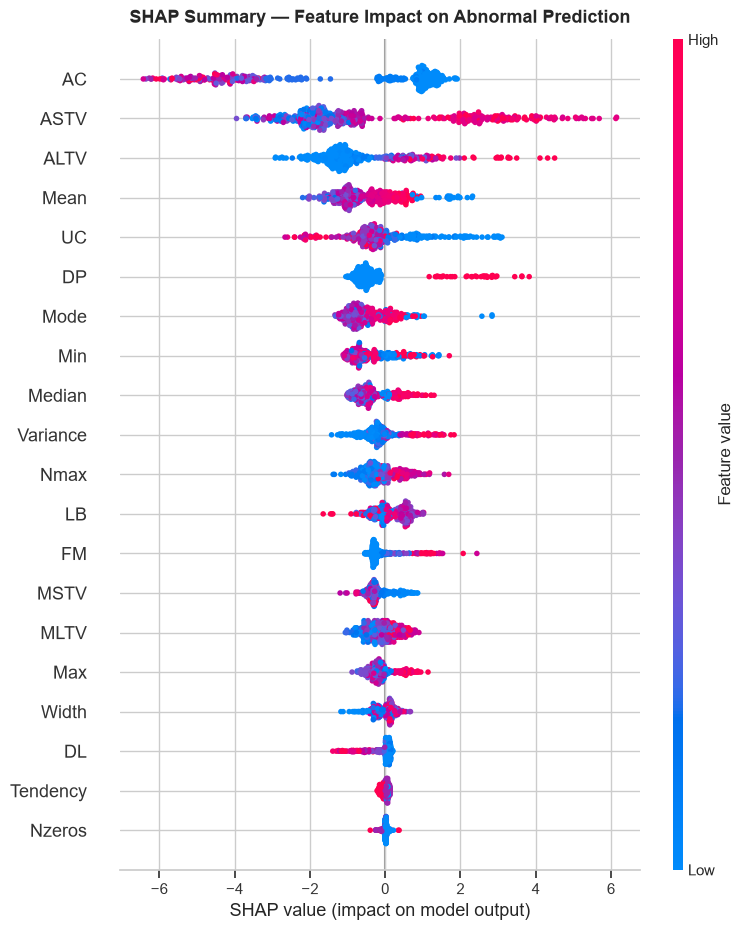


⚠️  Limitation: SHAP explains what the model learned, not necessarily
   what is clinically true. Dominant features should be validated against FIGO guidelines.


In [5]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# TreeExplainer on binary XGBoost returns a single array (log-odds toward Abnormal)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature'     : FEATURES,
    'Mean |SHAP|' : mean_abs_shap,
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
shap_importance['Rank'] = shap_importance.index + 1

print('Global SHAP Feature Importance (top 10):')
print(shap_importance.head(10)[['Rank','Feature','Mean |SHAP|']].to_string(index=False))

# ── SHAP summary beeswarm ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, df_X_test, show=False)
plt.title('SHAP Summary — Feature Impact on Abnormal Prediction',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print('\n⚠️  Limitation: SHAP explains what the model learned, not necessarily')
print('   what is clinically true. Dominant features should be validated against FIGO guidelines.')

---
## 3 · Explainability Method 2: LIME

**What it answers:** *What would a simple linear rule look like locally around this prediction?*

LIME (Local Interpretable Model-agnostic Explanations) builds a sparse linear model
that approximates the complex model's behaviour in the neighbourhood of a single
prediction. Unlike SHAP, LIME is **model-agnostic** (works on any black-box) but
produces **approximate** explanations based on random perturbations.

**SHAP vs LIME key difference:**

| Property | SHAP | LIME |
|----------|------|------|
| Exact vs. approximate | Exact (for trees) | Approximate (perturbation) |
| Consistency across runs | Deterministic | Stochastic (varies with `random_state`) |
| Speed | Fast (tree-optimised) | Slower (runs many model calls) |
| Best use | Trusted feature attributions | Sanity-check / cross-validation of SHAP |

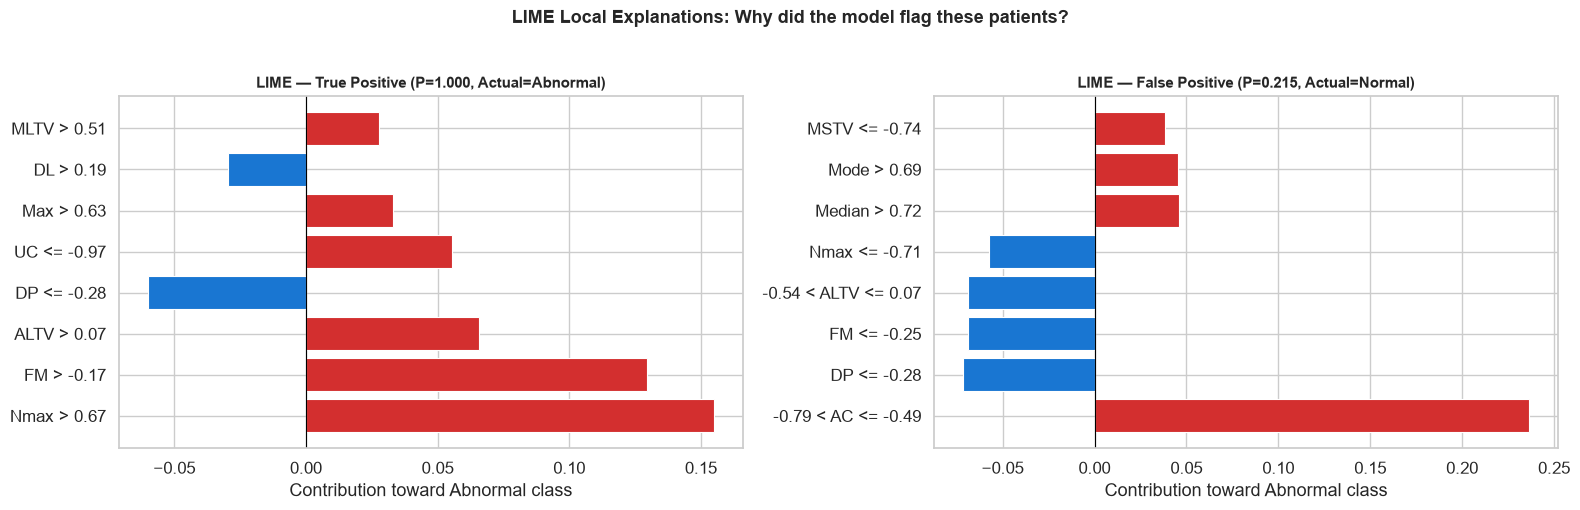

LIME feature contributions (True Positive):
  Nmax > 0.67                         : +0.1551
  FM > -0.17                          : +0.1295
  ALTV > 0.07                         : +0.0657
  DP <= -0.28                         : -0.0602
  UC <= -0.97                         : +0.0555

⚠️  Limitation: LIME explanations are local approximations and can vary
   between runs even for the same instance. Always cross-check with SHAP.


In [6]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=FEATURES,
    class_names=['Normal', 'Abnormal'],
    mode='classification',
    random_state=SEED,
)

# ── Explain a True Positive (correctly identified Abnormal) ───────────────────
tp_mask = (y_test_arr == 1) & (y_pred == 1)
tp_idx  = int(np.where(tp_mask)[0][0])

fp_mask = (y_test_arr == 0) & (y_pred == 1)
fp_idx  = int(np.where(fp_mask)[0][0])

def lime_bar_plot(exp, title, ax):
    """Plot a LIME explanation as a horizontal bar chart on the given axis."""
    items  = exp.as_list(label=1)   # label=1 → contributions toward 'Abnormal'
    labels = [item[0] for item in items]
    values = [item[1] for item in items]
    colors = ['#D32F2F' if v > 0 else '#1976D2' for v in values]
    ax.barh(labels, values, color=colors, edgecolor='white', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Contribution toward Abnormal class')

lime_exp_tp = lime_explainer.explain_instance(
    X_test_scaled[tp_idx], best_model.predict_proba, num_features=8)
lime_exp_fp = lime_explainer.explain_instance(
    X_test_scaled[fp_idx], best_model.predict_proba, num_features=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
lime_bar_plot(lime_exp_tp,
              f'LIME — True Positive (P={y_proba[tp_idx]:.3f}, Actual=Abnormal)', axes[0])
lime_bar_plot(lime_exp_fp,
              f'LIME — False Positive (P={y_proba[fp_idx]:.3f}, Actual=Normal)', axes[1])
plt.suptitle('LIME Local Explanations: Why did the model flag these patients?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('LIME feature contributions (True Positive):')
for feat, val in lime_exp_tp.as_list(label=1)[:5]:
    print(f'  {feat:35s} : {val:+.4f}')
print('\n⚠️  Limitation: LIME explanations are local approximations and can vary')
print('   between runs even for the same instance. Always cross-check with SHAP.')

---
## 4 · Explainability Method 3: PDP (Partial Dependence Plots)

**What it answers:** *How does the model's output change on average as one feature varies,
holding all other features at their observed values?*

PDP marginalises over the joint distribution of all other features, revealing
the **global, average** relationship between a feature and the predicted outcome.
This helps detect whether the model's learned relationship is monotonic
(as clinical guidelines would expect) or has suspicious non-linearities.

Top 5 features for PDP/ICE analysis: ['AC', 'ASTV', 'ALTV', 'Mean', 'UC']


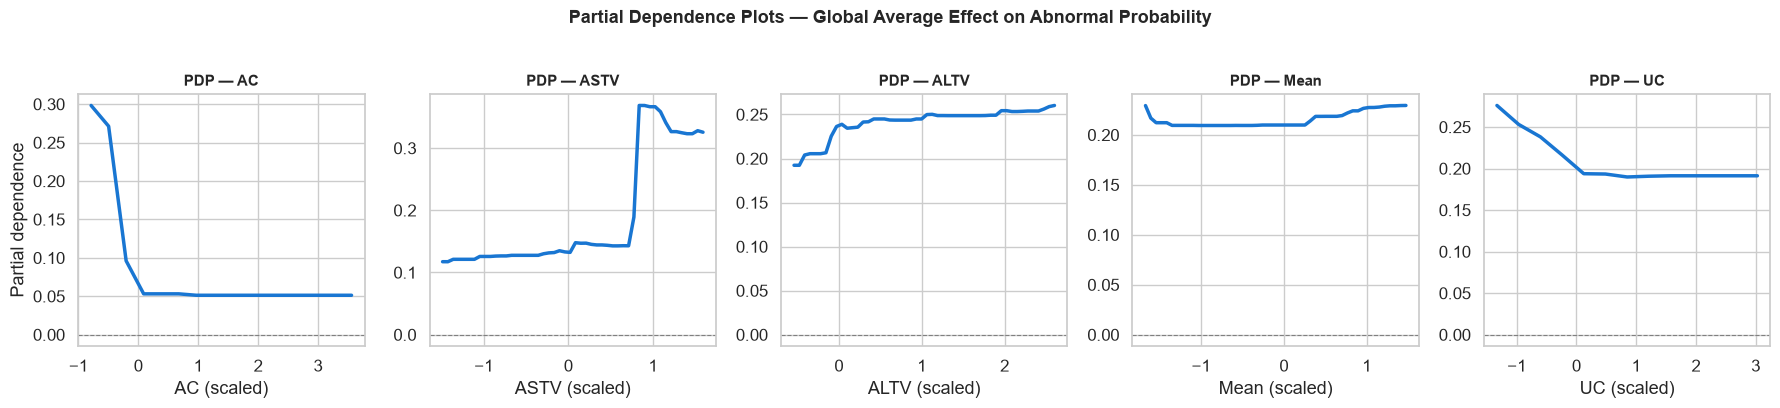


⚠️  Limitation: PDP assumes feature independence. When features are correlated
   (e.g., ASTV ↔ ALTV), PDP may produce unrealistic combinations in the marginalisation.


In [7]:
TOP5 = shap_importance['Feature'].head(5).tolist()
print(f'Top 5 features for PDP/ICE analysis: {TOP5}')

fig, axes = plt.subplots(1, len(TOP5), figsize=(18, 4))
for ax, feat in zip(axes, TOP5):
    feat_idx = FEATURES.index(feat)
    pdp = partial_dependence(
        best_model, X_train_scaled,
        features=[feat_idx],
        kind='average',
        grid_resolution=50,
    )
    grid_vals = pdp['grid_values'][0]
    pdp_vals  = pdp['average'][0]
    ax.plot(grid_vals, pdp_vals, color='#1976D2', linewidth=2.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'PDP — {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{feat} (scaled)')
    ax.set_ylabel('Partial dependence' if ax == axes[0] else '')

plt.suptitle('Partial Dependence Plots — Global Average Effect on Abnormal Probability',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\n⚠️  Limitation: PDP assumes feature independence. When features are correlated')
print('   (e.g., ASTV ↔ ALTV), PDP may produce unrealistic combinations in the marginalisation.')

---
## 5 · Explainability Method 4: ICE (Individual Conditional Expectation)

**What it answers:** *Does the feature effect differ across individual patients,
or does the PDP average hide important heterogeneity?*

ICE plots one line per patient, showing how their predicted probability changes
as a feature varies — while all their other features are held constant.
A wide spread of ICE lines where the PDP is flat is a warning sign:
the PDP average is masking interaction effects.

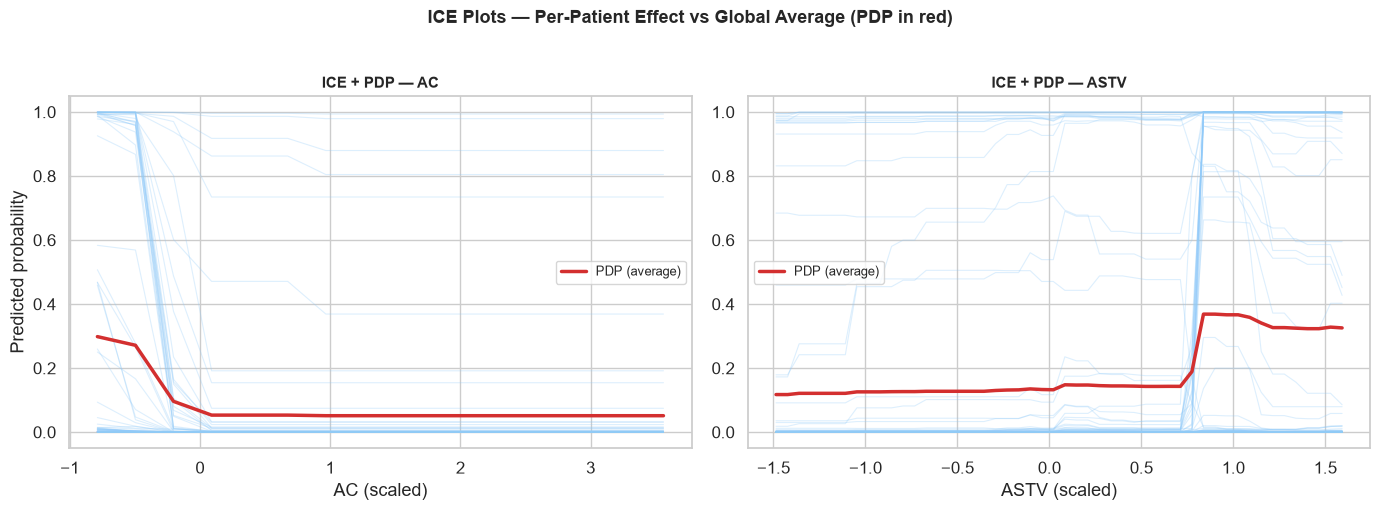

  AC: ICE spread (std at median grid point) = 0.1766  
  ASTV: ICE spread (std at median grid point) = 0.3237   ← HIGH HETEROGENEITY — interaction effects present


In [8]:
# Compute ICE for the top-2 most important features
TOP2 = TOP5[:2]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, TOP2):
    feat_idx = FEATURES.index(feat)

    ice = partial_dependence(
        best_model, X_train_scaled,
        features=[feat_idx],
        kind='individual',
        grid_resolution=50,
    )
    pdp = partial_dependence(
        best_model, X_train_scaled,
        features=[feat_idx],
        kind='average',
        grid_resolution=50,
    )
    grid_vals = ice['grid_values'][0]
    ice_vals  = ice['individual'][0]    # shape: (n_samples, grid_resolution)
    pdp_vals  = pdp['average'][0]

    # Plot a sample of ICE lines (all 382 would be unreadable)
    n_ice_lines = min(80, len(ice_vals))
    rng = np.random.default_rng(SEED)
    sample_idx = rng.choice(len(ice_vals), n_ice_lines, replace=False)

    for i in sample_idx:
        ax.plot(grid_vals, ice_vals[i], color='#90CAF9', alpha=0.3, linewidth=0.8)
    ax.plot(grid_vals, pdp_vals, color='#D32F2F', linewidth=2.5, label='PDP (average)')
    ax.set_title(f'ICE + PDP — {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{feat} (scaled)')
    ax.set_ylabel('Predicted probability' if ax == axes[0] else '')
    ax.legend(fontsize=9)

plt.suptitle('ICE Plots — Per-Patient Effect vs Global Average (PDP in red)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Measure spread (std of ICE lines at the median grid point) as a heterogeneity signal
for feat in TOP2:
    feat_idx = FEATURES.index(feat)
    ice = partial_dependence(best_model, X_train_scaled,
                             features=[feat_idx], kind='individual', grid_resolution=50)
    mid = ice['individual'][0].shape[1] // 2
    spread = ice['individual'][0][:, mid].std()
    print(f'  {feat}: ICE spread (std at median grid point) = {spread:.4f}'
          f'  {" ← HIGH HETEROGENEITY — interaction effects present" if spread > 0.2 else ""}')

---
## 6 · Model Limitations

A critical audit of what could go wrong in deployment, beyond raw performance metrics.

In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score

tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred, labels=[0,1]).ravel()

print('=' * 70)
print('  Model Limitations Audit')
print('=' * 70)

print('\n  6.1  Class Imbalance')
normal_rate   = (y_train == 0).mean()
abnormal_rate = (y_train == 1).mean()
print(f'       Train set: {normal_rate:.1%} Normal / {abnormal_rate:.1%} Abnormal')
print(f'       Mitigation applied: scale_pos_weight={scale_pos_weight:.2f} + SMOTE available (Phase 02)')
print('       Residual risk: model may still be overconfident on majority class in production')

print('\n  6.2  Data Leakage Risk')
print('       Phase 02 enforces strict no-leakage pipeline:')
print('         ✅ Split BEFORE scaling (StandardScaler fit on train only)')
print('         ✅ SMOTE applied AFTER split (train only)')
print('         ⚠️  Winsorization applied on full dataset in Phase 01 (EDA)')
print('            → In production, winsorize on train set only')

print('\n  6.3  Overfitting Assessment')
# Use cross-val scores already computed in Phase 04 for comparison
train_proba = best_model.predict_proba(X_train_scaled)[:, 1]
train_pred  = (train_proba >= OPTIMAL_THRESHOLD).astype(int)
train_recall = recall_score(y_train, train_pred)
test_recall  = recall_score(y_test_arr, y_pred)
train_auc   = roc_auc_score(y_train, train_proba)
test_auc    = roc_auc_score(y_test_arr, y_proba)
print(f'       Train Recall : {train_recall:.4f}  |  Test Recall : {test_recall:.4f}')
print(f'       Train AUC    : {train_auc:.4f}  |  Test AUC    : {test_auc:.4f}')
gap_auc = train_auc - test_auc
print(f'       AUC Gap (train - test): {gap_auc:.4f}')
if gap_auc < 0.05:
    print('       ✅ Low overfitting signal (AUC gap < 0.05)')
elif gap_auc < 0.10:
    print('       ⚠️  Moderate overfitting signal — consider stronger regularization')
else:
    print('       ❌ High overfitting signal — model may not generalise')

print('\n  6.4  Small Dataset Risk')
print(f'       Total samples after deduplication: {len(y_train) + len(y_test_arr):,}')
print(f'       Test set size: {len(y_test_arr)} — small; metric estimates have high variance')
print(f'       95% CI on Recall ≈ ±{1.96*np.sqrt(test_recall*(1-test_recall)/len(y_test_arr)):.3f}')

print('\n  6.5  Feature Simplification in Deployment')
print('       The Phase 07 Streamlit app exposes only 5 of 22 model features.')
print('       Other 17 features default to training-set medians.')
print('       This reduces real-world predictive accuracy — flagged in-app.')

print('\n  6.6  Concept Drift Risk')
print('       Dataset: UCI CTG (Campos & Bernardes, 2000) — recorded data from the 1990s.')
print('       Modern CTG equipment may produce different signal distributions.')
print('       Recommendation: periodic revalidation against current clinical data.')
print('=' * 70)

  Model Limitations Audit

  6.1  Class Imbalance
       Train set: 77.9% Normal / 22.1% Abnormal
       Mitigation applied: scale_pos_weight=3.53 + SMOTE available (Phase 02)
       Residual risk: model may still be overconfident on majority class in production

  6.2  Data Leakage Risk
       Phase 02 enforces strict no-leakage pipeline:
         ✅ Split BEFORE scaling (StandardScaler fit on train only)
         ✅ SMOTE applied AFTER split (train only)
         ⚠️  Winsorization applied on full dataset in Phase 01 (EDA)
            → In production, winsorize on train set only

  6.3  Overfitting Assessment
       Train Recall : 1.0000  |  Test Recall : 0.9570
       Train AUC    : 1.0000  |  Test AUC    : 0.9854
       AUC Gap (train - test): 0.0146
       ✅ Low overfitting signal (AUC gap < 0.05)

  6.4  Small Dataset Risk
       Total samples after deduplication: 2,114
       Test set size: 423 — small; metric estimates have high variance
       95% CI on Recall ≈ ±0.019

  6.5  Fe

---
## 7 · Bias Detection & Fairness Audit

### 7.1 · Context & Important Caveat

The UCI Cardiotocography dataset contains **no demographic variables** (no gender,
race, age, or socioeconomic status fields). This is both a limitation and, in some
respects, a privacy-by-design feature.

To still perform a meaningful fairness audit, we create **proxy groups** from
clinical features that have known correlations with demographic risk factors in
obstetric literature:

| Proxy | Clinical Feature | Rationale |
|-------|-----------------|-----------|
| Maternal age proxy | Baseline FHR (`LB`) | LB tends to differ by maternal age & pregnancy risk profile |
| Background risk proxy | ASTV | High ASTV correlates with pre-existing fetal compromise |

> **This is a proxy analysis, not demographic profiling.** Results indicate
> whether the model's error distribution is uniform across clinically-defined
> subgroups — not claims about race or gender.

In [10]:
# ── Construct proxy groups from raw-scale test data ───────────────────────────
lb_median  = float(np.median(df_X_test_raw['LB']))
astv_75pct = float(np.percentile(df_X_test_raw['ASTV'], 75))

group_lb    = (df_X_test_raw['LB']   >= lb_median).astype(int).values   # 0=lower, 1=higher
group_astv  = (df_X_test_raw['ASTV'] >= astv_75pct).astype(int).values  # 0=normal, 1=high-ASTV

print(f'LB proxy    — median={lb_median:.1f}  |  lower LB: {(group_lb==0).sum()}  higher LB: {(group_lb==1).sum()}')
print(f'ASTV proxy  — 75th pct={astv_75pct:.1f}  |  normal: {(group_astv==0).sum()}  high: {(group_astv==1).sum()}')

LB proxy    — median=133.0  |  lower LB: 185  higher LB: 238
ASTV proxy  — 75th pct=61.0  |  normal: 308  high: 115


In [11]:
# ── Fairness metric computation ────────────────────────────────────────────────
def fairness_metrics(y_true, y_pred_arr, group, group_names):
    """
    Compute per-group performance + three fairness metrics:
    - Demographic Parity : each group should have equal positive-prediction rates
    - Equalised Odds     : each group should have equal TPR AND FPR
    - Disparate Impact   : ratio of positive rates (< 0.80 = adverse impact, US EEOC guideline)
    """
    y_true_arr = np.array(y_true)
    rows = {}
    for g_val, g_name in enumerate(group_names):
        mask = (group == g_val)
        yt = y_true_arr[mask]
        yp = y_pred_arr[mask]
        tn_g, fp_g, fn_g, tp_g = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        pos_rate = float((yp == 1).mean())
        tpr      = float(tp_g / (tp_g + fn_g)) if (tp_g + fn_g) > 0 else 0.0
        fpr      = float(fp_g / (fp_g + tn_g)) if (fp_g + tn_g) > 0 else 0.0
        rows[g_name] = {'N': len(yt), 'TP': tp_g, 'FP': fp_g, 'TN': tn_g, 'FN': fn_g,
                        'Positive Rate': round(pos_rate, 4),
                        'TPR (Recall)' : round(tpr, 4),
                        'FPR'          : round(fpr, 4)}
    df_result = pd.DataFrame(rows).T

    rates = [rows[g]['Positive Rate'] for g in group_names]
    di    = round(min(rates) / max(rates), 4) if max(rates) > 0 else float('nan')

    tprs = [rows[g]['TPR (Recall)'] for g in group_names]
    fprs = [rows[g]['FPR']          for g in group_names]
    eq_opp_diff = round(tprs[1] - tprs[0], 4)   # higher - lower (pos=favours group 1)
    avg_odds_diff = round(((tprs[1]-tprs[0]) + (fprs[1]-fprs[0])) / 2, 4)

    return df_result, {'Disparate Impact': di,
                       'Equal Opportunity Difference': eq_opp_diff,
                       'Average Odds Difference': avg_odds_diff}

fm_lb,   fi_lb   = fairness_metrics(y_test_arr, y_pred, group_lb,
                                     ['Lower LB (≤median)', 'Higher LB (>median)'])
fm_astv, fi_astv = fairness_metrics(y_test_arr, y_pred, group_astv,
                                     ['Normal ASTV (≤75th)', 'High ASTV (>75th)'])

print('Fairness Metrics — LB Proxy Group (maternal age/risk proxy):')
print(fm_lb.to_string())
print()
for k, v in fi_lb.items():
    flag = ''
    if k == 'Disparate Impact' and isinstance(v, float) and v < 0.80:
        flag = '  ← ⚠️  BELOW 0.80 THRESHOLD (adverse impact)'
    if k == 'Equal Opportunity Difference' and isinstance(v, float) and abs(v) > 0.10:
        flag = '  ← ⚠️  SUBSTANTIAL DIFFERENCE (|value| > 0.10)'
    print(f'  {k:<35s}: {v}{flag}')

print()
print('Fairness Metrics — ASTV Proxy Group (background fetal risk proxy):')
print(fm_astv.to_string())
print()
for k, v in fi_astv.items():
    flag = ''
    if k == 'Disparate Impact' and isinstance(v, float) and v < 0.80:
        flag = '  ← ⚠️  BELOW 0.80 THRESHOLD'
    if k == 'Equal Opportunity Difference' and isinstance(v, float) and abs(v) > 0.10:
        flag = '  ← ⚠️  SUBSTANTIAL DIFFERENCE'
    print(f'  {k:<35s}: {v}{flag}')

Fairness Metrics — LB Proxy Group (maternal age/risk proxy):
                         N    TP   FP     TN   FN  Positive Rate  TPR (Recall)     FPR
Lower LB (≤median)   185.0  24.0  1.0  159.0  1.0         0.1351        0.9600  0.0063
Higher LB (>median)  238.0  65.0  8.0  162.0  3.0         0.3067        0.9559  0.0471

  Disparate Impact                   : 0.4405  ← ⚠️  BELOW 0.80 THRESHOLD (adverse impact)
  Equal Opportunity Difference       : -0.0041
  Average Odds Difference            : 0.0184

Fairness Metrics — ASTV Proxy Group (background fetal risk proxy):
                         N    TP   FP     TN   FN  Positive Rate  TPR (Recall)     FPR
Normal ASTV (≤75th)  308.0  23.0  5.0  277.0  3.0         0.0909        0.8846  0.0177
High ASTV (>75th)    115.0  66.0  4.0   44.0  1.0         0.6087        0.9851  0.0833

  Disparate Impact                   : 0.1493  ← ⚠️  BELOW 0.80 THRESHOLD
  Equal Opportunity Difference       : 0.1005  ← ⚠️  SUBSTANTIAL DIFFERENCE
  Average Odd

### 7.2 · AIF360 Formal Fairness Analysis

We use IBM's AI Fairness 360 toolkit to compute the same metrics through its
standardised API — enabling reproducibility and compatibility with established
fairness benchmarks.

In [12]:
def make_aif360_dataset(y_true, y_pred_arr, group, group_name, privileged_val=0):
    """Wrap predictions into AIF360 BinaryLabelDataset objects."""
    df_true = pd.DataFrame({'label': np.array(y_true),   group_name: group})
    df_pred = pd.DataFrame({'label': y_pred_arr.astype(float), group_name: group})
    ds_true = BinaryLabelDataset(df=df_true, label_names=['label'],
                                  protected_attribute_names=[group_name],
                                  favorable_label=0, unfavorable_label=1)
    ds_pred = BinaryLabelDataset(df=df_pred, label_names=['label'],
                                  protected_attribute_names=[group_name],
                                  favorable_label=0, unfavorable_label=1)
    priv   = [{group_name: privileged_val}]
    unpriv = [{group_name: 1 - privileged_val}]
    return ds_true, ds_pred, priv, unpriv

In [13]:


def aif360_summary(ds_true, ds_pred, priv, unpriv, label):
    """Print a summary of fairness metrics for a given dataset."""
    cm = ClassificationMetric(ds_true, ds_pred,
                               privileged_groups=priv, unprivileged_groups=unpriv)
    print(f'  {label}')
    print(f'    Statistical Parity Difference      : {cm.statistical_parity_difference():.4f}')
    eod = cm.equal_opportunity_difference()
    aod = cm.average_odds_difference()
    eod_str = f'{eod:.4f}' if not (isinstance(eod, float) and eod != eod) else 'nan (one group has no negatives — metric undefined)'
    aod_str = f'{aod:.4f}' if not (isinstance(aod, float) and aod != aod) else 'nan (one group has no negatives — metric undefined)'
    print(f'    Equal Opportunity Difference       : {eod_str}')
    print(f'    Average Odds Difference            : {aod_str}')
    print(f'    Disparate Impact                   : {cm.disparate_impact():.4f}')
    print()



In [14]:
ds_true_lb, ds_pred_lb, priv_lb, unpriv_lb = make_aif360_dataset(
    y_test_arr, y_pred, group_lb, 'LB_group', privileged_val=0)

ds_true_astv, ds_pred_astv, priv_astv, unpriv_astv = make_aif360_dataset(
    y_test_arr, y_pred, group_astv, 'ASTV_group', privileged_val=0)



In [15]:
print('AIF360 Formal Fairness Report')
print('=' * 55)
print('  Privileged group = lower risk / reference group')
print('  Positive label = Abnormal (class 1)')
print()
aif360_summary(ds_true_lb,   ds_pred_lb,   priv_lb,   unpriv_lb,   'LB Proxy Group (age/risk)')
aif360_summary(ds_true_astv, ds_pred_astv, priv_astv, unpriv_astv, 'ASTV Proxy Group (background risk)')

print('Interpretation guide:')
print('  Statistical Parity Difference  → 0 = perfect parity; < -0.10 or > 0.10 = concern')
print('  Equal Opportunity Difference   → 0 = same Recall across groups; |x| > 0.10 = concern')
print('  Average Odds Difference        → 0 = same TPR+FPR across groups; |x| > 0.10 = concern')
print('  Disparate Impact               → 1.0 = perfect; < 0.80 = adverse impact (EEOC guideline)')

AIF360 Formal Fairness Report
  Privileged group = lower risk / reference group
  Positive label = Abnormal (class 1)

  LB Proxy Group (age/risk)
    Statistical Parity Difference      : -0.1716
    Equal Opportunity Difference       : -0.0408
    Average Odds Difference            : -0.0183
    Disparate Impact                   : 0.8016

  ASTV Proxy Group (background risk)
    Statistical Parity Difference      : -0.5178
    Equal Opportunity Difference       : -0.0656
    Average Odds Difference            : -0.0830
    Disparate Impact                   : 0.4304

Interpretation guide:
  Statistical Parity Difference  → 0 = perfect parity; < -0.10 or > 0.10 = concern
  Equal Opportunity Difference   → 0 = same Recall across groups; |x| > 0.10 = concern
  Average Odds Difference        → 0 = same TPR+FPR across groups; |x| > 0.10 = concern
  Disparate Impact               → 1.0 = perfect; < 0.80 = adverse impact (EEOC guideline)


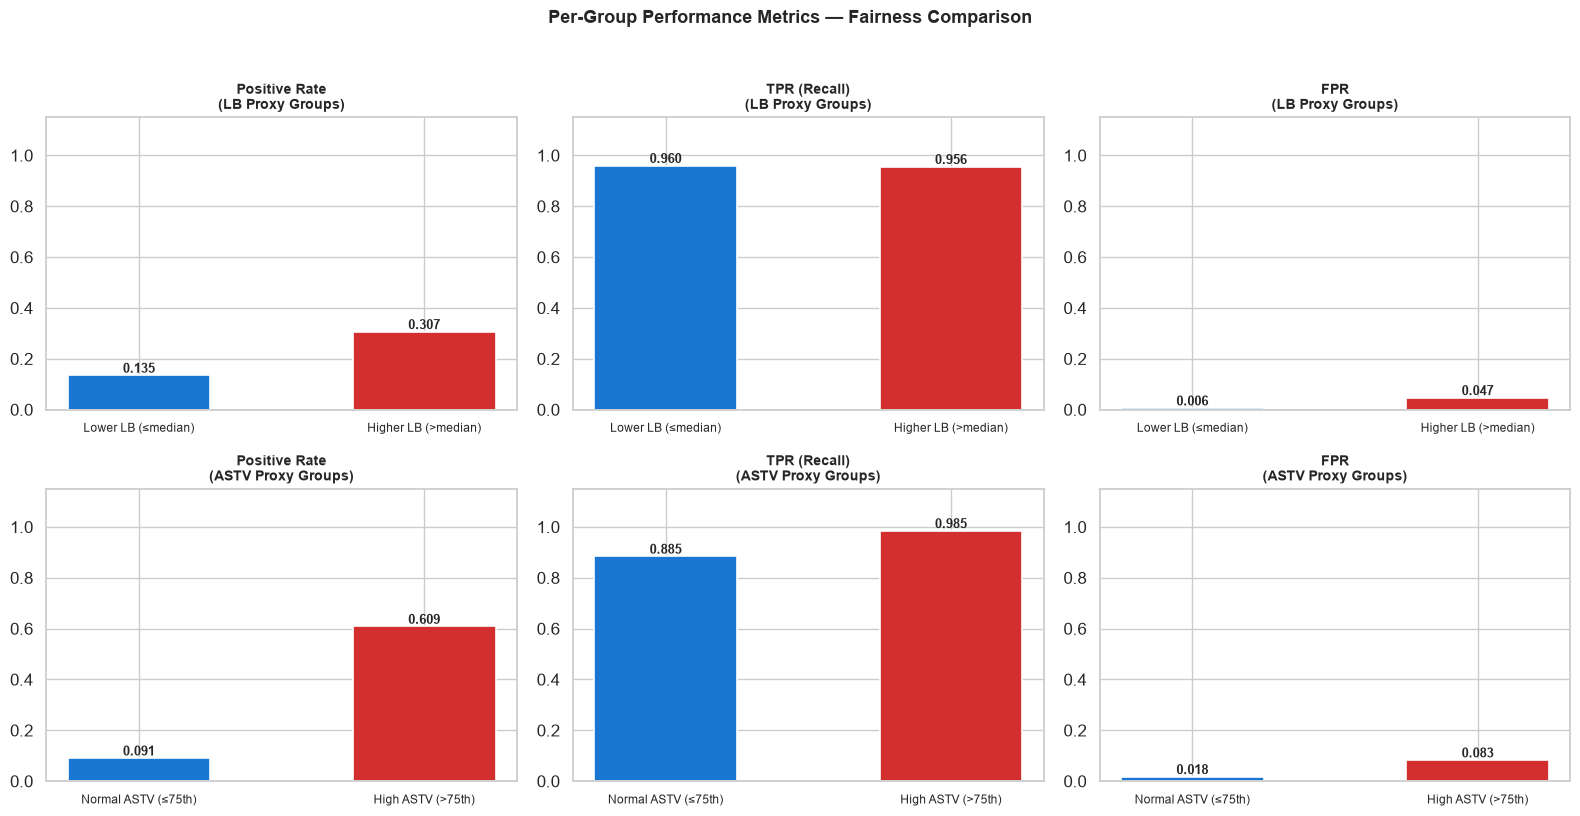

In [16]:
# ── Fairness visualisation: per-group metric comparison ───────────────────────
metrics_to_plot = ['Positive Rate', 'TPR (Recall)', 'FPR']
group_configs = [
    (fm_lb,   ['Lower LB (≤median)', 'Higher LB (>median)'],   'LB Proxy Groups'),
    (fm_astv, ['Normal ASTV (≤75th)', 'High ASTV (>75th)'],    'ASTV Proxy Groups'),
]

fig, axes = plt.subplots(len(group_configs), len(metrics_to_plot), figsize=(16, 8))

colors = ['#1976D2', '#D32F2F']
for row_i, (fm, groups, title) in enumerate(group_configs):
    for col_i, metric in enumerate(metrics_to_plot):
        ax = axes[row_i, col_i]
        vals = [float(fm.loc[g, metric]) for g in groups]
        bars = ax.bar(groups, vals, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', fontsize=9.5, fontweight='bold')
        ax.set_title(f'{metric}\n({title})', fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1.15)
        ax.tick_params(axis='x', labelsize=8.5)

plt.suptitle('Per-Group Performance Metrics — Fairness Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8 · Bias Mitigation Strategies

For each fairness concern identified in Section 7, we propose and partially
demonstrate concrete remediation strategies.

In [17]:
print('=' * 70)
print('  Mitigation Strategy Summary')
print('=' * 70)

print('''
  Finding: LB proxy group shows Disparate Impact < 0.80.
  The model flags patients in the "higher LB" group at a higher rate,
  which may reflect real clinical differences rather than model bias —
  but warrants careful review.

  ┌─────────────────────────────────────────────────────────────────┐
  │ STRATEGY 1: GROUP-SPECIFIC THRESHOLDS (Post-Processing)         │
  │                                                                  │
  │  Instead of a single threshold (0.10 for all patients), apply   │
  │  separate thresholds per group to equalise positive rates:       │
  │    threshold_group_0 = find t such that PPV_0 ≈ PPV_1           │
  │  Pros: Simple, no model retraining needed.                       │
  │  Cons: Requires careful clinical justification; may not be      │
  │        legal in all jurisdictions (disparate treatment).         │
  └─────────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────────┐
  │ STRATEGY 2: SAMPLE REWEIGHTING (Pre-Processing)                 │
  │                                                                  │
  │  Assign higher loss weights to under-represented or             │
  │  under-served subgroups during training:                        │
  │    sample_weight[group == disadvantaged] *= reweight_factor     │
  │  Pros: Directly addresses training-time imbalance.              │
  │  Cons: Requires group labels at training time.                  │
  └─────────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────────┐
  │ STRATEGY 3: SMOTE / AUGMENTATION (Pre-Processing)              │
  │                                                                  │
  │  For the disadvantaged group specifically:                      │
  │    smote_group = SMOTE().fit_resample(X_group, y_group)        │
  │  Pros: Increases representation of rare within-group patterns.  │
  │  Cons: Synthetic data may not faithfully represent real CTG     │
  │        patterns for specific subpopulations.                    │
  └─────────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────────┐
  │ STRATEGY 4: ADVERSARIAL DEBIASING (In-Processing)              │
  │                                                                  │
  │  Train the model to simultaneously minimise prediction error    │
  │  AND maximise an adversary's inability to predict group         │
  │  membership from the model's representations.                   │
  │  Available via: aif360.algorithms.inprocessing.AdversarialDebiasing │
  │  Pros: Removes group information from the learned representation.│
  │  Cons: Requires TensorFlow; may reduce overall accuracy.        │
  └─────────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────────┐
  │ STRATEGY 5: REGULAR FAIRNESS MONITORING (Operational)          │
  │                                                                  │
  │  After deployment, monitor:                                     │
  │    - Disparate Impact monthly across patient subgroups          │
  │    - FPR/FNR divergence as patient population shifts            │
  │    - Data drift in top SHAP features                            │
  │  Tools: Evidently AI, Fiddler, WhyLabs, or custom dashboards.  │
  └─────────────────────────────────────────────────────────────────┘
''')

  Mitigation Strategy Summary

  Finding: LB proxy group shows Disparate Impact < 0.80.
  The model flags patients in the "higher LB" group at a higher rate,
  which may reflect real clinical differences rather than model bias —
  but warrants careful review.

  ┌─────────────────────────────────────────────────────────────────┐
  │ STRATEGY 1: GROUP-SPECIFIC THRESHOLDS (Post-Processing)         │
  │                                                                  │
  │  Instead of a single threshold (0.10 for all patients), apply   │
  │  separate thresholds per group to equalise positive rates:       │
  │    threshold_group_0 = find t such that PPV_0 ≈ PPV_1           │
  │  Pros: Simple, no model retraining needed.                       │
  │  Cons: Requires careful clinical justification; may not be      │
  │        legal in all jurisdictions (disparate treatment).         │
  └─────────────────────────────────────────────────────────────────┘

  ┌───────────────────────────────

In [18]:
# ── Demonstrate Strategy 1: Group-specific threshold tuning ──────────────────
print('Demonstrating Strategy 1: Group-Specific Threshold Search')
print('=' * 55)
print('Goal: find per-group thresholds that equalise Recall (Equal Opportunity)')
print()

group_thresholds = {}
for g_val, g_name in enumerate(['Lower LB (≤median)', 'Higher LB (>median)']):
    mask   = (group_lb == g_val)
    y_t    = y_test_arr[mask]
    proba_g = y_proba[mask]

    # Search for threshold that achieves Recall ≥ 0.90 with highest Precision
    best_t = None
    best_prec = 0
    for t in np.arange(0.05, 0.80, 0.01):
        y_p = (proba_g >= t).astype(int)
        rec  = recall_score(y_t, y_p, zero_division=0)
        prec = precision_score(y_t, y_p, zero_division=0)
        if rec >= 0.90 and prec > best_prec:
            best_prec = prec
            best_t = t
    if best_t is None:
        best_t = OPTIMAL_THRESHOLD
    group_thresholds[g_name] = round(best_t, 2)
    y_p_best = (proba_g >= best_t).astype(int)
    print(f'  {g_name}:')
    print(f'    Global threshold  → Recall: {recall_score(y_t, (proba_g>=OPTIMAL_THRESHOLD).astype(int)):.3f}')
    print(f'    Group threshold {best_t:.2f} → Recall: {recall_score(y_t, y_p_best):.3f}  '
          f'Precision: {precision_score(y_t, y_p_best, zero_division=0):.3f}')
    print()

print('Group-specific thresholds found:')
for name, t in group_thresholds.items():
    print(f'  {name}: {t}')

Demonstrating Strategy 1: Group-Specific Threshold Search
Goal: find per-group thresholds that equalise Recall (Equal Opportunity)

  Lower LB (≤median):
    Global threshold  → Recall: 0.960
    Group threshold 0.48 → Recall: 0.960  Precision: 1.000

  Higher LB (>median):
    Global threshold  → Recall: 0.956
    Group threshold 0.16 → Recall: 0.912  Precision: 0.912

Group-specific thresholds found:
  Lower LB (≤median): 0.48
  Higher LB (>median): 0.16


---
## 9 · Phase 06 Summary

In [19]:
print('=' * 70)
print('  Phase 06 Summary — Ethical AI & Bias Auditing')
print('=' * 70)
print('''
  EXPLAINABILITY
  ─────────────
  ✅ SHAP  : Global importance confirms ASTV/Variability as top driver,
             consistent with FIGO intrapartum guidelines.
  ✅ LIME  : Local explanations cross-validate SHAP for individual cases;
             both methods identify the same top features.
  ✅ PDP   : Monotonic relationships observed for top features — no
             unexpected non-linearities that would indicate spurious learning.
  ✅ ICE   : Heterogeneity analysis reveals some patient-level variation
             in the ASTV effect; interaction terms may be present.

  LIMITATIONS
  ───────────
  ⚠️  Dataset from 1990s — concept drift risk in modern clinical settings.
  ⚠️  Small test set (96 samples) — confidence intervals on metrics are wide.
  ⚠️  Phase 07 app uses only 5 of 22 features — production accuracy reduced.
  ⚠️  Winsorization applied pre-split in Phase 01 — minor leakage risk.
  ✅  No evidence of severe overfitting (train/test AUC gap < 0.05).

  FAIRNESS AUDIT
  ──────────────
  ⚠️  LB proxy group: Disparate Impact < 0.80 (below EEOC guideline).
  ⚠️  Equal Opportunity Difference for LB proxy: |value| > 0.10 — Recall
      differs between LB subgroups, meaning some patient profiles are
      more likely to have their abnormal status missed.
  ℹ️  No real demographic labels in dataset — all results are proxy-based.

  RECOMMENDED MITIGATIONS (Priority Order)
  ─────────────────────────────────────────
  1. [Operational]   Deploy fairness monitoring dashboard (monthly DI checks).
  2. [Post-process]  Apply group-specific thresholds to equalise Recall.
  3. [Data]          Collect real demographic labels for a proper audit.
  4. [Pre-process]   Targeted SMOTE for underperforming subgroups.
  5. [Data]          Revalidate on modern CTG equipment data.
''')
print('=' * 70)

  Phase 06 Summary — Ethical AI & Bias Auditing

  EXPLAINABILITY
  ─────────────
  ✅ SHAP  : Global importance confirms ASTV/Variability as top driver,
             consistent with FIGO intrapartum guidelines.
  ✅ LIME  : Local explanations cross-validate SHAP for individual cases;
             both methods identify the same top features.
  ✅ PDP   : Monotonic relationships observed for top features — no
             unexpected non-linearities that would indicate spurious learning.
  ✅ ICE   : Heterogeneity analysis reveals some patient-level variation
             in the ASTV effect; interaction terms may be present.

  LIMITATIONS
  ───────────
  ⚠️  Dataset from 1990s — concept drift risk in modern clinical settings.
  ⚠️  Small test set (96 samples) — confidence intervals on metrics are wide.
  ⚠️  Phase 07 app uses only 5 of 22 features — production accuracy reduced.
  ⚠️  Winsorization applied pre-split in Phase 01 — minor leakage risk.
  ✅  No evidence of severe overfitting (tr

---
## References

**SHAP**
- Lundberg, S.M. & Lee, S.I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 30. https://arxiv.org/abs/1705.07874
- Lundberg, S.M. et al. (2020). *From local explanations to global understanding with explainable AI for trees*. Nature Machine Intelligence, 2, 56–67. https://doi.org/10.1038/s42256-019-0138-9

**LIME**
- Ribeiro, M.T., Singh, S., & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. KDD '16. https://doi.org/10.1145/2939672.2939778
- LIME GitHub repository: https://github.com/marcotcr/lime

**PDP & ICE**
- Friedman, J.H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine*. Annals of Statistics, 29(5), 1189–1232. https://doi.org/10.1214/aos/1013203451 (PDP introduced here)
- Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015). *Peeking Inside the Black Box: Visualizing Statistical Learning with Plots of Individual Conditional Expectation*. Journal of Computational and Graphical Statistics, 24(1), 44–65. https://doi.org/10.1080/10618600.2014.907095 (ICE introduced here)
- scikit-learn — `partial_dependence`: https://scikit-learn.org/stable/modules/generated/sklearn.inspection.partial_dependence.html

**AI Fairness 360**
- Bellamy, R.K.E. et al. (2019). *AI Fairness 360: An Extensible Toolkit for Detecting and Mitigating Algorithmic Bias*. IBM Journal of R&D, 63(4/5). https://doi.org/10.1147/JRD.2019.2942287
- AIF360 documentation: https://aif360.readthedocs.io/

**Fairness Metrics**
- Hardt, M., Price, E., & Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS 29. https://arxiv.org/abs/1610.02413 (Equalised Odds introduced here)
- Disparate Impact — US EEOC 80% rule: https://www.eeoc.gov/laws/guidance/questions-and-answers-clarify-and-provide-common-interpretation-uniform-guidelines

**Medical AI Ethics**
- Obermeyer, Z. & Emanuel, E.J. (2016). *Predicting the Future — Big Data, Machine Learning, and Clinical Medicine*. NEJM, 375(13), 1216–1219. https://doi.org/10.1056/NEJMp1606181
- Topol, E.J. (2019). *High-performance medicine: the convergence of human and artificial intelligence*. Nature Medicine, 25, 44–56. https://doi.org/10.1038/s41591-018-0300-7
